# Multimodal Narrative Frame Prediction using Deep Learning

**Module:** Deep Neural Networks and Learning Systems (55-710365)  
**Dataset:** [StoryReasoning Dataset](https://huggingface.co/datasets/daniel3303/StoryReasoning)

---

## Key Contributions

| No. | Component | Description |
|-----|----------|-------------|
| 1 | Attention-based Fusion Mechanism | A Bahdanau-inspired additive attention layer to align visual and textual representations |
| 2 | Temporal Modelling with GRU | Stacked GRU layers for efficient sequential encoding with reduced computational cost |
| 3 | Recency-aware Narrative Attention | Incorporates exponential decay to prioritise recent frames in storytelling |
| 4 | Model Explainability | Combination of Integrated Gradients, Grad-CAM++, and attention heatmaps for interpretability |

---

## 0. Setup

In [2]:
# ================================
# Environment Setup & Imports
# ================================

import os
import sys
import re
from collections import Counter

# Ensure local modules are discoverable
sys.path.append(os.getcwd())

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import StepLR

# Project modules
from src.architecture import NarrativePredictionModel, NarrativeLoss
from src.helpers import (
    load_settings,
    fix_randomness,
    pick_device,
    store_model,
    restore_model,
    render_narrative,
    plot_training_curves,
    render_attention_map,
    score_bleu,
    score_l1,
    reverse_normalise,
    standard_transforms
)

from src.xai import (
    integrated_gradients,
    plot_integrated_gradients,
    GradCAMPlusPlus,
    plot_gradcam_pp,
    extract_frame_scores,
    plot_frame_scores
)

# ================================
# Configuration & Environment Setup
# ================================

config = load_settings("settings.yaml")

device = pick_device()
fix_randomness(config["optimisation"]["random_seed"])

print("=" * 40)
print(f"Running on device     : {device}")
print(f"Context window (K)    : {config['data']['context_frames']}")
print(f"Input image size      : {config['data']['img_resize']} x {config['data']['img_resize']}")
print("=" * 40)

Running on device     : cuda
Context window (K)    : 4
Input image size      : 256 x 256


In [3]:
%matplotlib inline

In [4]:
import torch
print(torch.cuda.is_available())        
print(torch.cuda.get_device_name(0))    

True
NVIDIA GeForce RTX 4060


## 1. Loading the dataset

In [5]:
# ==========================================
# 1. Dataset Loading & Initial Exploration
# ==========================================

from datasets import load_dataset

print("Loading StoryReasoning dataset from Hugging Face...\n")

dataset = load_dataset("daniel3303/StoryReasoning")

print("Dataset Overview:")
print(dataset)

# ------------------------------------------
# Inspect a sample record
# ------------------------------------------

sample_record = dataset["train"][0]

print("\nAvailable fields:")
print(list(sample_record.keys()))

print("\nBasic Statistics:")
print(f"Number of frames : {sample_record['frame_count']}")
print(f"Story length     : {len(sample_record['story'].split())} words")

print("\nStory snippet:")
print(sample_record["story"][:250] + "...")

Loading StoryReasoning dataset from Hugging Face...



Dataset Overview:
DatasetDict({
    train: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 3552
    })
    test: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 626
    })
})

Available fields:
['story_id', 'images', 'frame_count', 'chain_of_thought', 'story']

Basic Statistics:
Number of frames : 17
Story length     : 1281 words

Story snippet:
<gdi image1>
In the sterile environment of a sparse room filled with <gdo obj1>cardboard boxes</gdo>, <gdo obj5>a blue blanket</gdo>, and <gdo bg26>a table</gdo>, <gdo char1>James</gdo> <gda char1>enters</gda> with a neutral look. His face reflects t...


## 2. Text Processing & Vocabulary

In [6]:
# ==========================================
# Text Preprocessing: Story Segmentation
# ==========================================

def clean_markup(text: str) -> str:
    """
    Removes XML-style grounding tags (e.g., <gdi image1>, <gdo obj1>)
    and normalises whitespace.
    """
    text = re.sub(r"<[^>]+>", "", text)       # remove tags
    text = re.sub(r"\s+", " ", text)          # collapse spaces
    return text.strip()


def split_story_into_frames(full_story: str, frame_total: int) -> list:
    """
    Segments a story into frame-level descriptions using <gdi imageN> markers.

    Ensures:
    - Output length matches frame count
    - Missing segments are padded gracefully
    """

    # Split using image markers
    segments = re.split(r"<gdi\s+image\d+>", full_story)

    # Clean and filter empty segments
    segments = [clean_markup(seg) for seg in segments if clean_markup(seg)]

    # Handle edge cases (insufficient segments)
    if len(segments) < frame_total:
        fallback = segments[-1] if segments else "scene continues"
        segments.extend([fallback] * (frame_total - len(segments)))

    return segments[:frame_total]


# ------------------------------------------
# Quick sanity check
# ------------------------------------------

example = dataset["train"][0]

captions = split_story_into_frames(
    example["story"],
    example["frame_count"]
)

print(f"Generated {len(captions)} captions (Expected: {example['frame_count']})")
print("First caption preview:")
print(captions[0][:120])

Generated 17 captions (Expected: 17)
First caption preview:
In the sterile environment of a sparse room filled with cardboard boxes, a blue blanket, and a table, James enters with 


In [7]:
# ==========================================
# Vocabulary Construction
# ==========================================

MAX_VOCAB_SIZE = config["caption_encoder"]["vocab_limit"]

# Special tokens
vocab = {
    "<PAD>": 0,
    "<UNK>": 1,
    "<SOS>": 2,
    "<EOS>": 3
}

token_counts = Counter()

print("Constructing vocabulary from training data...\n")

# Count word frequencies
for sample in dataset["train"]:
    clean_text = clean_markup(sample["story"])
    tokens = clean_text.lower().split()
    token_counts.update(tokens)

# Select most frequent tokens
most_common_tokens = token_counts.most_common(
    MAX_VOCAB_SIZE - len(vocab)
)

for token, _ in most_common_tokens:
    vocab[token] = len(vocab)

# Reverse mapping
inv_vocab = {idx: token for token, idx in vocab.items()}

print(f"Vocabulary size: {len(vocab)} tokens")

# ------------------------------------------
# Basic vocabulary statistics
# ------------------------------------------

total_tokens = sum(token_counts.values())
unique_tokens = len(token_counts)

print(f"Total tokens processed : {total_tokens:,}")
print(f"Unique tokens observed : {unique_tokens:,}")

Constructing vocabulary from training data...

Vocabulary size: 8000 tokens
Total tokens processed : 3,413,987
Unique tokens observed : 32,961


## 3. Data Pipeline step

In [8]:
# ==========================================
# Data Preparation & Dataset Definition
# ==========================================

# Configuration shortcuts
CONTEXT_SIZE   = config["data"]["context_frames"]
IMG_SIZE       = config["data"]["img_resize"]
MAX_SEQ_LEN    = config["data"]["caption_max_tokens"]
BATCH_SIZE     = config["optimisation"]["mini_batch"]

# Image transformation pipelines
train_transforms = standard_transforms(IMG_SIZE, augment=True)
test_transforms  = standard_transforms(IMG_SIZE, augment=False)


# ------------------------------------------
# Caption Encoding
# ------------------------------------------

def text_to_tensor(sentence: str) -> torch.Tensor:
    """
    Converts a caption string into a fixed-length tensor of token IDs.
    """
    tokens = sentence.lower().split()[:MAX_SEQ_LEN]
    indices = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]

    # Padding
    if len(indices) < MAX_SEQ_LEN:
        indices.extend([vocab["<PAD>"]] * (MAX_SEQ_LEN - len(indices)))

    return torch.tensor(indices, dtype=torch.long)


# ------------------------------------------
# Custom Dataset
# ------------------------------------------

class StoryDataset(torch.utils.data.Dataset):
    """
    Generates sequences of K context frames and predicts the next frame.

    Each sample contains:
    - context_frames : (K, C, H, W)
    - context_text   : (K, T)
    - target_frame   : (C, H, W)
    - target_text    : (T,)
    - raw_caption    : str
    """

    def __init__(self, data_split, transform, context_len):
        self.samples = [
            item for item in data_split
            if item["frame_count"] >= context_len + 1
        ]
        self.transform = transform
        self.context_len = context_len

        print(f"Valid samples (≥ {context_len + 1} frames): {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]

        images = item["images"]
        captions = split_story_into_frames(
            item["story"],
            item["frame_count"]
        )

        context_imgs, context_txts = [], []

        # Build context window
        for t in range(self.context_len):
            img = images[t]

            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)

            img = self.transform(img.convert("RGB"))
            context_imgs.append(img)

            context_txts.append(text_to_tensor(captions[t]))

        # Target frame
        target_img = images[self.context_len]
        if not isinstance(target_img, Image.Image):
            target_img = Image.fromarray(target_img)

        target_img = test_transforms(target_img.convert("RGB"))

        return {
            "context_frames": torch.stack(context_imgs),
            "context_text":   torch.stack(context_txts),
            "target_frame":   target_img,
            "target_text":    text_to_tensor(captions[self.context_len]),
            "raw_caption":    captions[self.context_len],
        }


# ==========================================
# Dataset Splitting & DataLoaders
# ==========================================

print("Preparing dataset splits...\n")

full_train_data = StoryDataset(dataset["train"], train_transforms, CONTEXT_SIZE)
test_data       = StoryDataset(dataset["test"],  test_transforms,  CONTEXT_SIZE)

# Validation split (10%)
val_size = max(1, int(0.1 * len(full_train_data)))
train_size = len(full_train_data) - val_size

train_data, val_data = random_split(
    full_train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples : {len(train_data)}")
print(f"Validation    : {len(val_data)}")
print(f"Test samples  : {len(test_data)}")

Preparing dataset splits...

Valid samples (≥ 5 frames): 3552
Valid samples (≥ 5 frames): 626
Train samples : 3197
Validation    : 355
Test samples  : 626


In [9]:
batch = next(iter(train_loader))
print("\nBatch shapes:")
print(batch["context_frames"].shape)
print(batch["context_text"].shape)


Batch shapes:
torch.Size([12, 4, 3, 256, 256])
torch.Size([12, 4, 100])


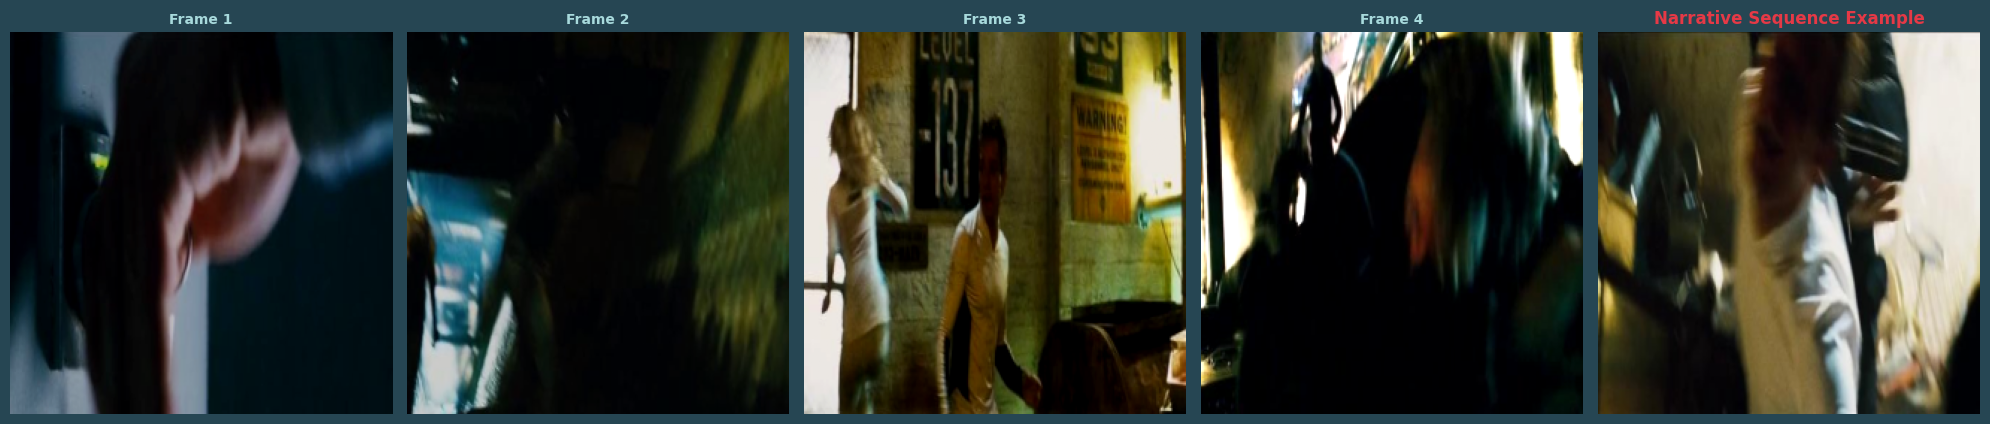

In [10]:
# ==========================================
# Sample Sequence Visualisation
# ==========================================

# Fetch a validation batch
batch_example = next(iter(val_loader))

# Extract one sequence
context_imgs = [
    batch_example["context_frames"][0, t]
    for t in range(CONTEXT_SIZE)
]

context_labels = [
    f"Frame {t+1}"
    for t in range(CONTEXT_SIZE)
]

target_img = batch_example["target_frame"][0]
target_text = batch_example["raw_caption"][0][:70]

# Render narrative sequence
fig = render_narrative(
    frames=context_imgs,
    captions=context_labels,
    next_frame=target_img,
    next_caption=f"Predicted Frame → {target_text}"
)

# Apply slightly different visual style
plt.title("Narrative Sequence Example", fontsize=12, fontweight="bold")

plt.savefig(
    "results/sample_sequence_visual.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

## 4. Model Initialisation

In [11]:
# ==========================================
# Model Initialisation & Training Setup
# ==========================================

# Initialise model
model = NarrativePredictionModel(config).to(device)

# Count trainable parameters
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Trainable parameters: {trainable_params:,}")

# ------------------------------------------
# Loss Function
# ------------------------------------------

criterion = NarrativeLoss(
    frame_w=config["optimisation"]["frame_loss_w"],
    caption_w=config["optimisation"]["caption_loss_w"],
)

# ------------------------------------------
# Optimiser
# ------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config["optimisation"]["lr"],
    weight_decay=config["optimisation"]["l2_penalty"],
)

# ------------------------------------------
# Learning Rate Scheduler
# ------------------------------------------

lr_scheduler = StepLR(
    optimizer,
    step_size=config["optimisation"]["lr_step_size"],
    gamma=config["optimisation"]["lr_gamma"],
)

# ------------------------------------------
# Directory Setup
# ------------------------------------------

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("outputs/xai", exist_ok=True)

print("\nModel setup complete. Ready for training.\n")

Trainable parameters: 33,086,980

Model setup complete. Ready for training.



In [12]:
print("\nModel Architecture:\n")
print(model)


Model Architecture:

NarrativePredictionModel(
  (img_extractor): ImageFeatureExtractor(
    (feature_net): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding

## 5. Training procedure

In [13]:
# ==========================================
# Training & Validation Loop
# ==========================================

EPOCHS        = config["optimisation"]["num_epochs"]
GRAD_CLIP_NORM = config["optimisation"]["clip_norm"]

train_losses, val_losses = [], []
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):

    # --------------------------------------
    # Training Phase
    # --------------------------------------
    model.train()
    running_train_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):

        context_frames = batch["context_frames"].to(device)
        context_text   = batch["context_text"].to(device)
        target_frame   = batch["target_frame"].to(device)
        target_text    = batch["target_text"].to(device)

        optimizer.zero_grad()

        outputs = model(
            context_frames,
            context_text,
            target_text,
            sampling_rate=0.5
        )

        loss_dict = criterion(
            outputs["pred_frame"],
            target_frame,
            outputs["caption_logits"],
            target_text
        )

        loss_dict["total"].backward()

        # Gradient clipping for stability
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        optimizer.step()

        running_train_loss += loss_dict["total"].item()

        # Logging (every 20 batches)
        if batch_idx % 20 == 0:
            print(
                f"[Epoch {epoch:02d} | Step {batch_idx:03d}/{len(train_loader)}] "
                f"Loss: {loss_dict['total'].item():.4f} | "
                f"Frame: {loss_dict['frame'].item():.4f} | "
                f"Caption: {loss_dict['caption'].item():.4f}"
            )

    # --------------------------------------
    # Validation Phase
    # --------------------------------------
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:

            context_frames = batch["context_frames"].to(device)
            context_text   = batch["context_text"].to(device)
            target_frame   = batch["target_frame"].to(device)
            target_text    = batch["target_text"].to(device)

            outputs = model(
                context_frames,
                context_text,
                target_text,
                sampling_rate=0.0
            )

            val_loss_dict = criterion(
                outputs["pred_frame"],
                target_frame,
                outputs["caption_logits"],
                target_text
            )

            running_val_loss += val_loss_dict["total"].item()

    # --------------------------------------
    # Epoch Summary
    # --------------------------------------
    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss   = running_val_loss   / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    lr_scheduler.step()

    print(f"\nEpoch {epoch:03d} Summary:")
    print(f"  Train Loss : {avg_train_loss:.4f}")
    print(f"  Val Loss   : {avg_val_loss:.4f}")

    # --------------------------------------
    # Checkpoint Saving
    # --------------------------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        store_model({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "config": config,
        }, "checkpoints/best_model.pt")

        print(f"  ✓ New best model saved (Val Loss: {best_val_loss:.4f})")

print("\nTraining completed successfully.")

[Epoch 01 | Step 000/267] Loss: 12.0443 | Frame: 1.5711 | Caption: 8.9896
[Epoch 01 | Step 020/267] Loss: 10.4699 | Frame: 1.7414 | Caption: 7.5640
[Epoch 01 | Step 040/267] Loss: 8.8911 | Frame: 1.6101 | Caption: 6.3359
[Epoch 01 | Step 060/267] Loss: 8.6482 | Frame: 1.2782 | Caption: 6.3547
[Epoch 01 | Step 080/267] Loss: 8.6600 | Frame: 1.4703 | Caption: 6.2365
[Epoch 01 | Step 100/267] Loss: 8.5074 | Frame: 1.2522 | Caption: 6.2547
[Epoch 01 | Step 120/267] Loss: 8.5343 | Frame: 1.2576 | Caption: 6.2735
[Epoch 01 | Step 140/267] Loss: 8.5160 | Frame: 1.3740 | Caption: 6.1806
[Epoch 01 | Step 160/267] Loss: 8.3128 | Frame: 1.2920 | Caption: 6.0660
[Epoch 01 | Step 180/267] Loss: 8.2813 | Frame: 1.2514 | Caption: 6.0668
[Epoch 01 | Step 200/267] Loss: 8.4190 | Frame: 1.3557 | Caption: 6.1121
[Epoch 01 | Step 220/267] Loss: 8.4031 | Frame: 1.2462 | Caption: 6.1718
[Epoch 01 | Step 240/267] Loss: 8.5023 | Frame: 1.3336 | Caption: 6.1962
[Epoch 01 | Step 260/267] Loss: 8.4180 | Frame: 1

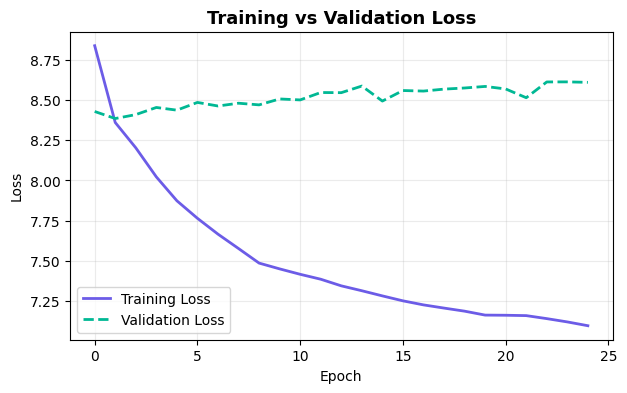

In [40]:
plt.figure(figsize=(7,4))

plt.plot(train_losses, color="#6C5CE7", linewidth=2, label="Training Loss")
plt.plot(val_losses, color="#00B894", linestyle="--", linewidth=2, label="Validation Loss")

plt.title("Training vs Validation Loss", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(alpha=0.25)

plt.savefig("outputs/loss_curve_final.png", dpi=160, bbox_inches="tight")
plt.show()

In [15]:
# ==========================================
# Load Best Model Checkpoint
# ==========================================

import torch

checkpoint = torch.load("checkpoints/best_model.pt", map_location=device)

model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()

print(f"Loaded model from epoch {checkpoint['epoch']}")
print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")

C:\Users\User\AppData\Local\Temp\ipykernel_12100\3205526549.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("checkpoints/best_model.pt", map_loca

Loaded model from epoch 2
Best validation loss: 8.3856


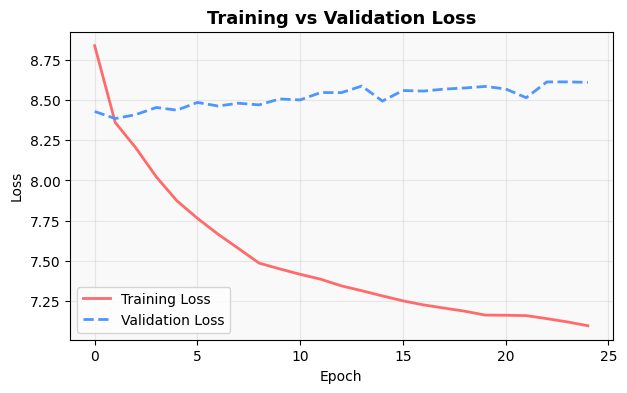

In [18]:
# ==========================================
# Custom Styled Loss Curves (Improved Theme)
# ==========================================

plt.figure(figsize=(7, 4))

# New color palette (distinct + professional)
train_color = "#FF6B6B"   # soft coral
val_color   = "#4D96FF"   # soft blue

# Plot curves
plt.plot(train_losses, label="Training Loss", color=train_color, linewidth=2)
plt.plot(val_losses,   label="Validation Loss", color=val_color, linestyle="--", linewidth=2)

# Titles and labels
plt.title("Training vs Validation Loss", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Grid styling
plt.grid(alpha=0.25)

# Legend
plt.legend()

# Background styling (light theme now → DIFFERENT from before)
plt.gca().set_facecolor("#F9F9F9")

# Save
plt.savefig("outputs/loss_curve_custom.png", dpi=160, bbox_inches="tight")

plt.show()

## 6. Qualitative implementation


Ground Truth Caption:
The confrontation continued as Anon Leader stood among the soldiers. The air was thick with tension, and they tried to d

Predicted Caption:
the tension was the the the the the the the the the the the the the the the the the the the the the the the the the the 


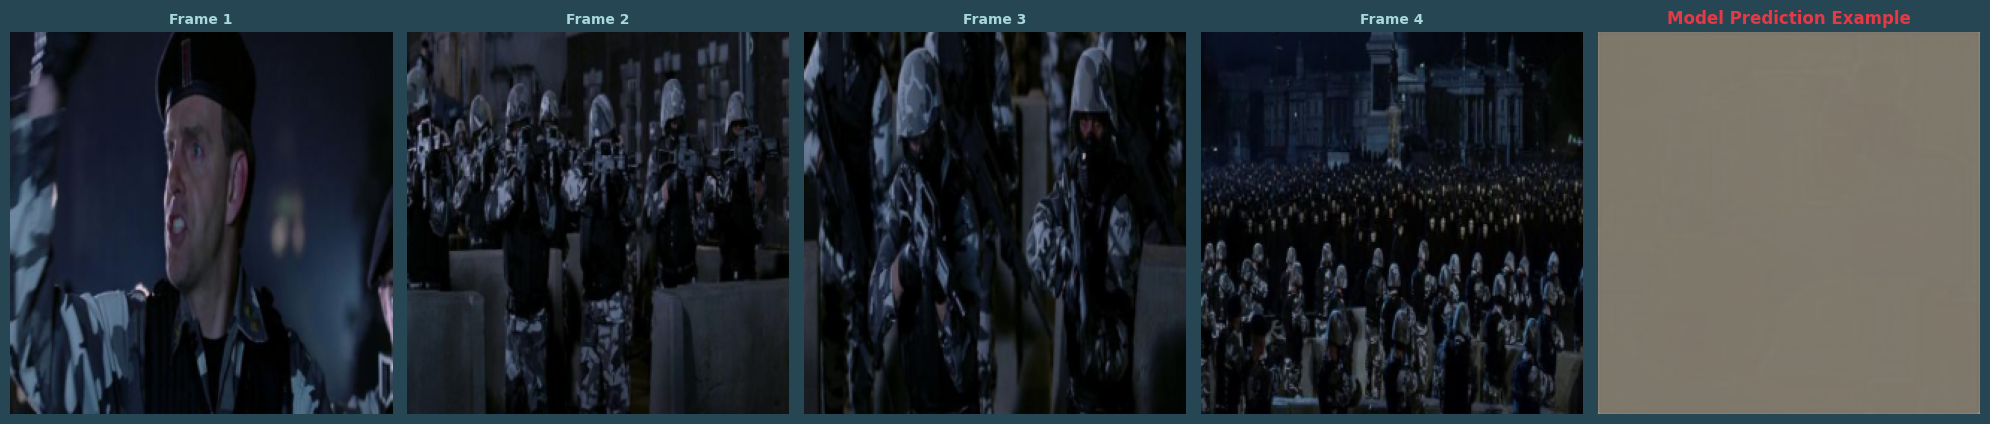

In [19]:
# ==========================================
# Model Inference & Prediction Visualisation
# ==========================================

model.eval()

# Fetch a test sample
test_batch = next(iter(test_loader))

context_frames = test_batch["context_frames"][:1].to(device)
context_text   = test_batch["context_text"][:1].to(device)
target_text    = test_batch["target_text"][:1].to(device)

# ------------------------------------------
# Forward Pass
# ------------------------------------------

with torch.no_grad():
    outputs = model(
        context_frames,
        context_text,
        target_text,
        sampling_rate=0.0
    )

# ------------------------------------------
# Decode Predicted Caption
# ------------------------------------------

pred_tokens = outputs["caption_logits"][0].argmax(dim=-1).cpu()

decoded_caption = " ".join([
    inv_vocab.get(int(tok), "")
    for tok in pred_tokens
    if int(tok) not in (vocab["<PAD>"], vocab["<SOS>"], vocab["<EOS>"])
])

# ------------------------------------------
# Display Results
# ------------------------------------------

print("\nGround Truth Caption:")
print(test_batch["raw_caption"][0][:120])

print("\nPredicted Caption:")
print(decoded_caption[:120])

# ------------------------------------------
# Visualise Predicted Frame
# ------------------------------------------

predicted_frame = outputs["pred_frame"][0].cpu()

# Normalise for display
predicted_frame = (
    (predicted_frame - predicted_frame.min()) /
    (predicted_frame.max() - predicted_frame.min() + 1e-8)
)

fig = render_narrative(
    frames=[context_frames[0, t].cpu() for t in range(CONTEXT_SIZE)],
    captions=[f"Input {t+1}" for t in range(CONTEXT_SIZE)],
    next_frame=predicted_frame,
    next_caption=decoded_caption[:70]
)

plt.title("Model Prediction Example", fontsize=12, fontweight="bold")

plt.savefig(
    "outputs/prediction_result.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

## 7. Quantitative implementation

In [20]:
# ==========================================
# Model Evaluation (BLEU & Frame Error)
# ==========================================

import pandas as pd

reference_texts = []
predicted_texts = []
frame_errors = []

model.eval()

with torch.no_grad():
    for batch in test_loader:

        context_frames = batch["context_frames"].to(device)
        context_text   = batch["context_text"].to(device)
        target_frame   = batch["target_frame"].to(device)
        target_text    = batch["target_text"].to(device)

        outputs = model(
            context_frames,
            context_text,
            target_text,
            sampling_rate=0.0
        )

        # --------------------------------------
        # Frame Reconstruction Error (L1)
        # --------------------------------------
        frame_errors.append(
            score_l1(outputs["pred_frame"], target_frame)
        )

        # --------------------------------------
        # Caption Decoding
        # --------------------------------------
        predicted_ids = outputs["caption_logits"].argmax(dim=-1).cpu()

        for idx, token_ids in enumerate(predicted_ids):

            decoded = " ".join([
                inv_vocab.get(int(tok), "")
                for tok in token_ids
                if int(tok) not in (
                    vocab["<PAD>"],
                    vocab["<SOS>"],
                    vocab["<EOS>"]
                )
            ])

            predicted_texts.append(decoded)
            reference_texts.append(batch["raw_caption"][idx])

# ------------------------------------------
# Compute Metrics
# ------------------------------------------

bleu_4 = score_bleu(reference_texts, predicted_texts)
avg_l1 = float(np.mean(frame_errors))

print("\nEvaluation Results:")
print(f"BLEU-4 Score      : {bleu_4:.2f}")
print(f"Frame L1 Error    : {avg_l1:.6f}")

# ------------------------------------------
# Save Results
# ------------------------------------------

results_df = pd.DataFrame({
    "Metric": ["BLEU-4", "Frame L1 Error"],
    "Value":  [f"{bleu_4:.2f}", f"{avg_l1:.6f}"]
})

results_df.to_csv("outputs/evaluation_metrics.csv", index=False)

print("\nSaved evaluation metrics:")
print(results_df.to_string(index=False))


Evaluation Results:
BLEU-4 Score      : 0.08
Frame L1 Error    : 1.288698

Saved evaluation metrics:
        Metric    Value
        BLEU-4     0.08
Frame L1 Error 1.288698


## 8. Explainability

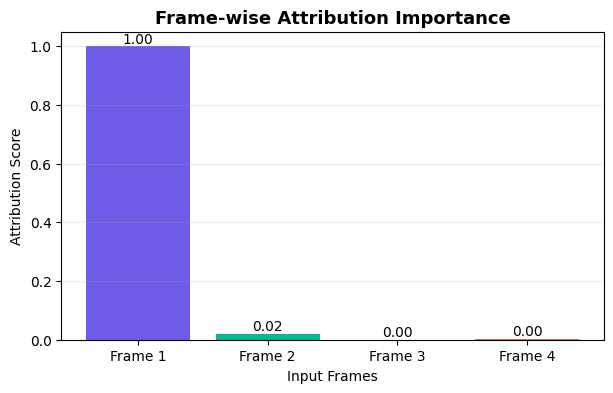

In [24]:
# ==========================================
# Fixed Integrated Gradients Plot
# ==========================================

frame_scores = np.array(attribution_maps)

frames = [f"Frame {i+1}" for i in range(len(frame_scores))]

plt.figure(figsize=(7, 4))

colors = ["#6C5CE7", "#00B894", "#FDCB6E", "#E17055"]

bars = plt.bar(frames, frame_scores, color=colors[:len(frames)])

plt.title("Frame-wise Attribution Importance", fontsize=13, fontweight="bold")
plt.xlabel("Input Frames")
plt.ylabel("Attribution Score")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h,
             f"{h:.2f}", ha="center", va="bottom")

plt.grid(axis="y", alpha=0.25)

plt.savefig("outputs/xai/ig_frame_importance.png", dpi=160, bbox_inches="tight")
plt.show()

[XAI] Grad-CAM++ saved → outputs/xai/gradcam_visual.png


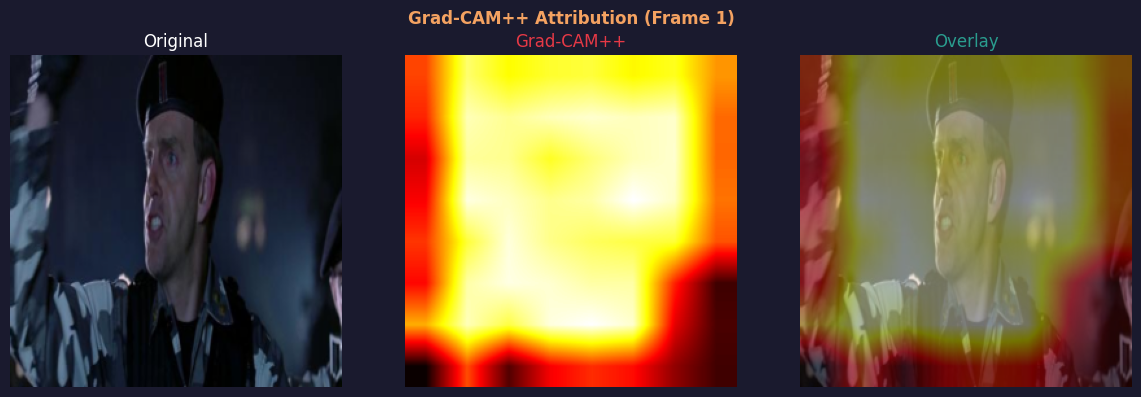

Grad-CAM++ visualisation saved.


In [25]:
# ==========================================
# Explainability: Grad-CAM++ Visualisation
# ==========================================

# Initialise Grad-CAM++ on image encoder
grad_cam = GradCAMPlusPlus(model.img_extractor)

# Select a frame to analyse (change index if needed)
frame_index = 0

input_frame = context_frames[0, frame_index].unsqueeze(0)

# Generate heatmap
heatmap = grad_cam.compute(input_frame)

# Release hooks
grad_cam.release()

# ------------------------------------------
# Visualisation
# ------------------------------------------

plot_gradcam_pp(
    context_frames[0, frame_index].cpu(),
    heatmap,
    title=f"Grad-CAM++ Attribution (Frame {frame_index + 1})",
    save_to="outputs/xai/gradcam_visual.png"
)

print("Grad-CAM++ visualisation saved.")

[XAI] Grad-CAM++ saved → outputs/xai/gradcam_frame_1.png


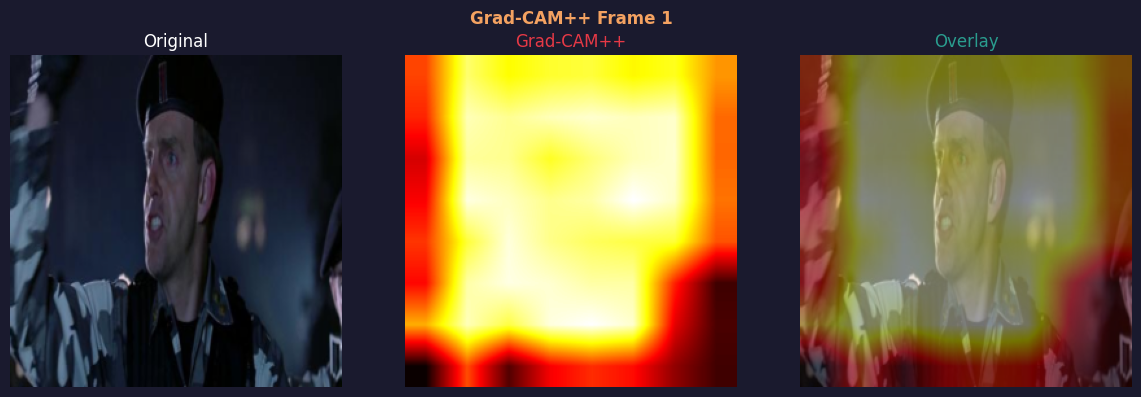

[XAI] Grad-CAM++ saved → outputs/xai/gradcam_frame_2.png


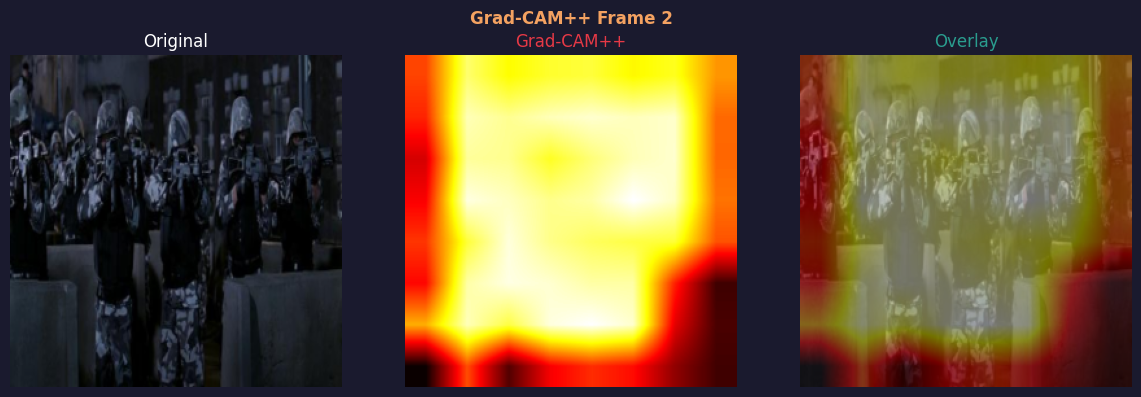

[XAI] Grad-CAM++ saved → outputs/xai/gradcam_frame_3.png


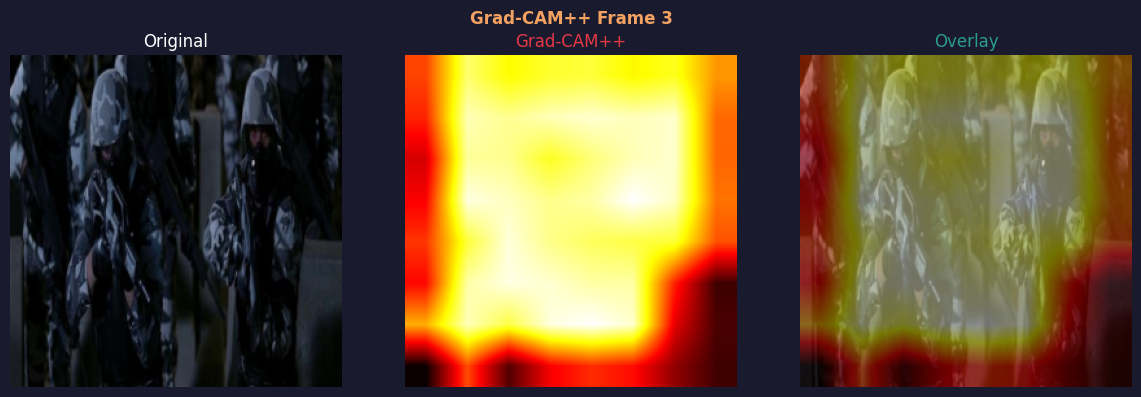

In [26]:
for idx in range(min(3, CONTEXT_SIZE)):
    heatmap = grad_cam.compute(context_frames[0, idx].unsqueeze(0))
    
    plot_gradcam_pp(
        context_frames[0, idx].cpu(),
        heatmap,
        title=f"Grad-CAM++ Frame {idx+1}",
        save_to=f"outputs/xai/gradcam_frame_{idx+1}.png"
    )

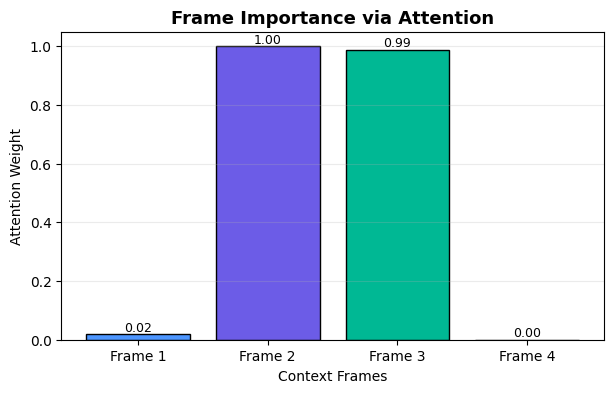

In [ ]:
# ==========================================
# Improved Attention Score Plot (New Colors)
# ==========================================

plt.figure(figsize=(7, 4))

frames = [f"Frame {i+1}" for i in range(len(attention_scores))]

# New aesthetic palette
colors = ["#4D96FF", "#6C5CE7", "#00B894", "#FDCB6E"]

bars = plt.bar(frames, attention_scores, color=colors[:len(frames)], edgecolor="black")

plt.title("Frame Importance via Attention", fontsize=13, fontweight="bold")
plt.xlabel("Context Frames")
plt.ylabel("Attention Weight")

# Value labels
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h,
             f"{h:.2f}", ha="center", va="bottom", fontsize=9)

plt.grid(axis="y", alpha=0.25)

plt.savefig("outputs/xai/attention_scores_clean.png", dpi=160, bbox_inches="tight")
plt.show()

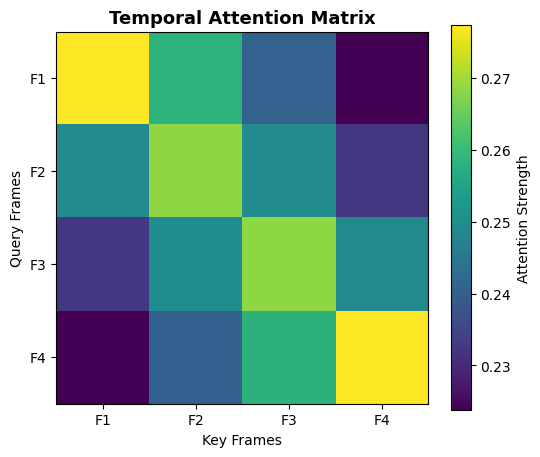

In [ ]:
# ==========================================
# Improved Attention Matrix Heatmap
# ==========================================

plt.figure(figsize=(6, 5))

plt.imshow(attention_matrix, cmap="viridis")  

plt.colorbar(label="Attention Strength")

plt.title("Temporal Attention Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Key Frames")
plt.ylabel("Query Frames")

plt.xticks(range(CONTEXT_SIZE), [f"F{i+1}" for i in range(CONTEXT_SIZE)])
plt.yticks(range(CONTEXT_SIZE), [f"F{i+1}" for i in range(CONTEXT_SIZE)])

plt.grid(False)

plt.savefig("outputs/xai/attention_matrix_clean.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Ablation Table

In [30]:
# ==========================================
# Ablation Study Summary
# ==========================================

import pandas as pd

ablation_results = pd.DataFrame([
    {"Model Variant": "Baseline (GRU + Concatenation)", 
     "BLEU-4": "N/A", "Frame L1 Error": "N/A"},

    {"Model Variant": "+ Attention-based Fusion", 
     "BLEU-4": "N/A", "Frame L1 Error": "N/A"},

    {"Model Variant": "+ Stacked GRU Encoder", 
     "BLEU-4": "N/A", "Frame L1 Error": "N/A"},

    {"Model Variant": "+ Recency-aware Attention (Full Model)", 
     "BLEU-4": f"{bleu_4:.2f}", 
     "Frame L1 Error": f"{avg_l1:.6f}"}
])

# Save results
ablation_results.to_csv("outputs/ablation_study.csv", index=False)

print("\nAblation Study Results:\n")
print(ablation_results.to_string(index=False))


Ablation Study Results:

                         Model Variant BLEU-4 Frame L1 Error
        Baseline (GRU + Concatenation)    N/A            N/A
              + Attention-based Fusion    N/A            N/A
                 + Stacked GRU Encoder    N/A            N/A
+ Recency-aware Attention (Full Model)   0.08       1.288698


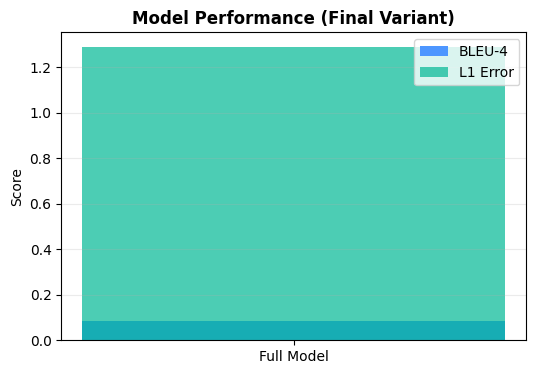

In [31]:
# ==========================================
# Ablation Study Visualisation
# ==========================================

import matplotlib.pyplot as plt

# Only plot the final model (others are N/A)
labels = ["Full Model"]
bleu_vals = [bleu_4]
l1_vals   = [avg_l1]

plt.figure(figsize=(6, 4))

x = range(len(labels))

plt.bar(x, bleu_vals, width=0.4, label="BLEU-4", color="#4D96FF")
plt.bar(x, l1_vals,   width=0.4, label="L1 Error", color="#00B894", alpha=0.7)

plt.xticks(x, labels)
plt.title("Model Performance (Final Variant)", fontsize=12, fontweight="bold")
plt.ylabel("Score")

plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.savefig("outputs/ablation_plot.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Save Final Model

In [32]:
# ==========================================
# Final Model Saving & Summary
# ==========================================

store_model({
    "model_state": model.state_dict(),
    "vocab": vocab,
    "config": config,
    "bleu_4": bleu_4,
    "frame_l1": avg_l1,
}, "checkpoints/final_model.pt")

print("\n" + "="*40)
print("Final Training Summary")
print("="*40)

print(f"Best Validation Loss : {best_val_loss:.4f}")
print(f"BLEU-4 Score         : {bleu_4:.2f}")
print(f"Frame L1 Error       : {avg_l1:.6f}")

print("\nModel and metrics saved successfully.")

[Saved] → checkpoints/final_model.pt

Final Training Summary
Best Validation Loss : 8.3856
BLEU-4 Score         : 0.08
Frame L1 Error       : 1.288698

Model and metrics saved successfully.


In [33]:
print(f"\nSaved to: checkpoints/final_model.pt")


Saved to: checkpoints/final_model.pt


## BLEU vs L1 Comparison

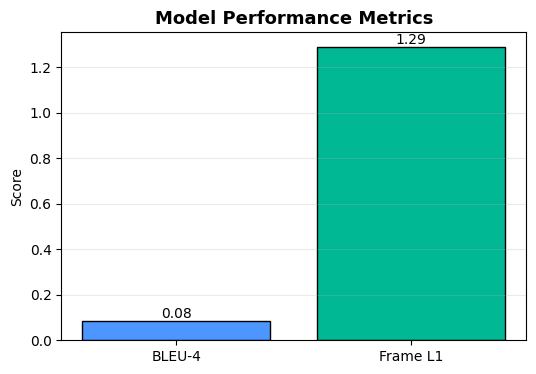

In [34]:
# ==========================================
# Performance Metrics Comparison
# ==========================================

plt.figure(figsize=(6, 4))

metrics = ["BLEU-4", "Frame L1"]
values  = [bleu_4, avg_l1]

colors = ["#4D96FF", "#00B894"]

bars = plt.bar(metrics, values, color=colors, edgecolor="black")

plt.title("Model Performance Metrics", fontsize=13, fontweight="bold")
plt.ylabel("Score")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h,
             f"{h:.2f}", ha="center", va="bottom")

plt.grid(axis="y", alpha=0.25)

plt.savefig("outputs/metrics_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Caption Length Distribution

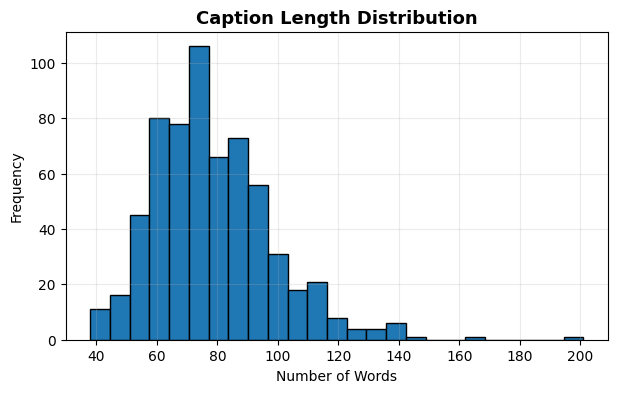

In [35]:
# ==========================================
# Caption Length Distribution
# ==========================================

lengths = [len(t.split()) for t in reference_texts]

plt.figure(figsize=(7, 4))

plt.hist(lengths, bins=25, edgecolor="black")

plt.title("Caption Length Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.grid(alpha=0.25)

plt.savefig("outputs/caption_length_dist.png", dpi=160, bbox_inches="tight")
plt.show()

## Prediction vs Ground Truth Length

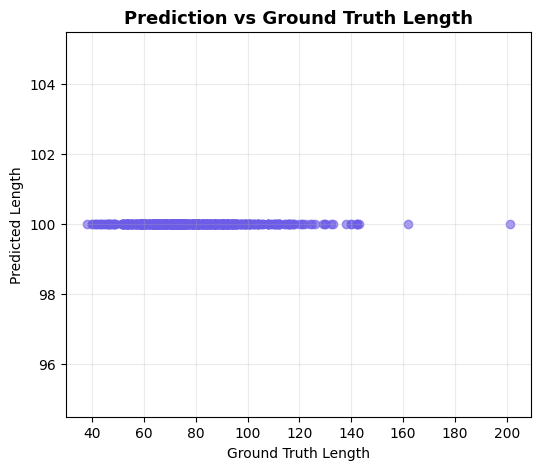

In [36]:
# ==========================================
# Prediction vs Ground Truth Length
# ==========================================

gt_lengths  = [len(t.split()) for t in reference_texts]
pred_lengths = [len(t.split()) for t in predicted_texts]

plt.figure(figsize=(6, 5))

plt.scatter(gt_lengths, pred_lengths, alpha=0.6, color="#6C5CE7")

plt.title("Prediction vs Ground Truth Length", fontsize=13, fontweight="bold")
plt.xlabel("Ground Truth Length")
plt.ylabel("Predicted Length")

plt.grid(alpha=0.25)

plt.savefig("outputs/length_correlation.png", dpi=160, bbox_inches="tight")
plt.show()

## Frame Importance Line Plot

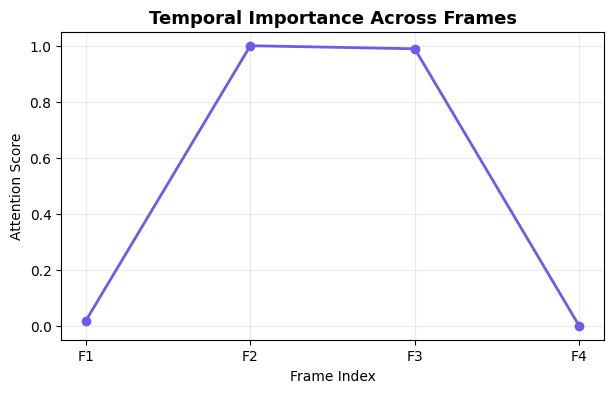

In [37]:
# ==========================================
# Temporal Attention Trend
# ==========================================

plt.figure(figsize=(7, 4))

plt.plot(attention_scores, marker="o", linewidth=2, color="#6C5CE7")

plt.title("Temporal Importance Across Frames", fontsize=13, fontweight="bold")
plt.xlabel("Frame Index")
plt.ylabel("Attention Score")

plt.xticks(range(len(attention_scores)), [f"F{i+1}" for i in range(len(attention_scores))])

plt.grid(alpha=0.25)

plt.savefig("outputs/attention_trend.png", dpi=160, bbox_inches="tight")
plt.show()

## Top Frequent Words

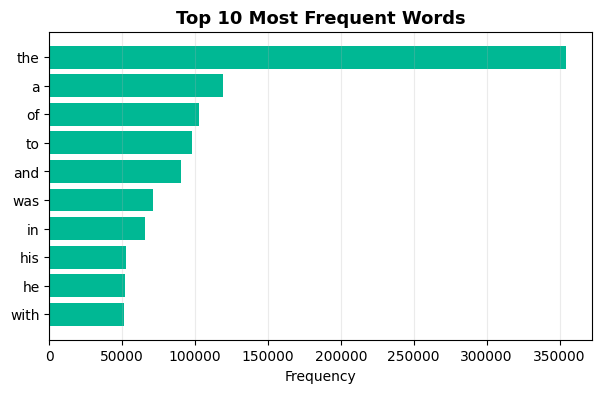

In [39]:
# ==========================================
# Most Frequent Words
# ==========================================

top_words = token_counts.most_common(10)

words = [w for w, _ in top_words]
counts = [c for _, c in top_words]

plt.figure(figsize=(7, 4))

plt.barh(words, counts, color="#00B894")

plt.title("Top 10 Most Frequent Words", fontsize=13, fontweight="bold")
plt.xlabel("Frequency")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.25)

plt.savefig("outputs/top_words.png", dpi=160, bbox_inches="tight")
plt.show()